# Kitaev Chain: Dense BdG Hamiltonian

Builds the **Kitaev chain** p-wave BdG Hamiltonian as a plain dense matrix — no tensor network methods.

The BdG Hamiltonian for $N$ sites is a $2N \times 2N$ matrix in Nambu space:

$$H_\mathrm{BdG} = \begin{pmatrix} H_\mathrm{kin} & \Delta A \\ \Delta A^\dagger & -H_\mathrm{kin} \end{pmatrix}$$

where:
- $H_\mathrm{kin}$ — $N\times N$ OBC kinetic matrix: $[H_\mathrm{kin}]_{ij} = -t(\delta_{i,j\pm1}) - \mu\,\delta_{ij}$
- $A$ — nearest-neighbour pairing: $A_{i+1,i} = 1$ (OBC)
- $\Delta$ — p-wave pairing amplitude

**Topological phase transition** (thermodynamic limit): $|\mu| = 2t$.

In [1]:
using LinearAlgebra
using Plots

---
## Build the dense BdG Hamiltonian

In [20]:
N = 200      # number of physical sites
t = 1.0     # nearest-neighbour hopping
Δ = 0.5     # p-wave pairing amplitude
μ = -0.5    # chemical potential  (topological phase: |μ| < 2t)

# Kinetic part: tridiagonal OBC tight-binding
H_kin = diagm(0  => fill(-μ, N),
              1  => fill(-t, N-1),
              -1 => fill(-t, N-1))

# Pairing matrix: A[i+1, i] = 1  (nearest-neighbour, OBC)
A = diagm(-1 => ones(N-1)) + diagm(1 => -ones(N-1))

# Full 2N × 2N BdG matrix in Nambu basis (c, c†)
H_BdG = [H_kin      Δ*A;
         Δ*A'    -H_kin]

println("H_BdG size : ", size(H_BdG))
println("Hermitian  : ", norm(H_BdG - H_BdG') < 1e-12)

H_BdG size : (400, 400)
Hermitian  : true


---
## Heatmap of the BdG matrix

The block structure is visible: diagonal blocks ($H_\mathrm{kin}$ and $-H_\mathrm{kin}$) and off-diagonal pairing blocks ($\Delta A$ and $\Delta A^\dagger$).

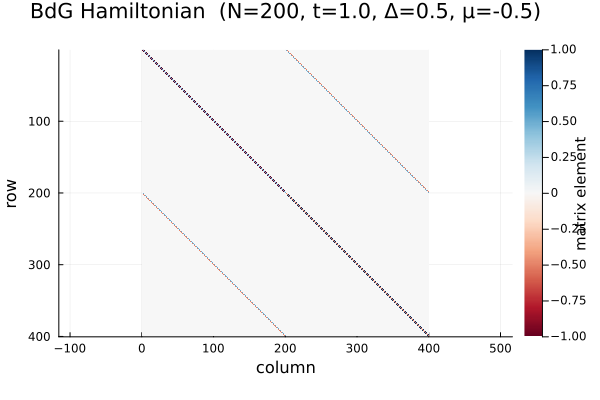

In [29]:
p_heatmap = heatmap(real.(H_BdG);
        yflip=true,
        color=:RdBu,
        aspect_ratio=:equal,
        title="BdG Hamiltonian  (N=$(N), t=$(t), Δ=$(Δ), μ=$(μ))",
        xlabel="column", ylabel="row",
        colorbar_title="matrix element")

---
## Dense KPM density of states

The **Kernel Polynomial Method** expands the spectral function in Chebyshev polynomials $T_n$:

$$\rho(\omega) \approx \frac{1}{\pi\sqrt{1-\tilde\omega^2}\cdot N_\mathrm{cheb}\cdot a} \left[ g_0\,\mu_0 + 2\sum_{n=1}^{N_\mathrm{cheb}-1} g_n\,\mu_n\,T_n(\tilde\omega) \right], \qquad \tilde\omega = \frac{\omega - b}{a}$$

where $(b, a)$ are the spectral center and half-width, and $\mu_n = \mathrm{tr}[T_n(\tilde H)]$ are the **Chebyshev moments** computed by the three-term recurrence.

The **Jackson kernel** $g_n = (N_\mathrm{cheb}-n)\cos\frac{\pi n}{N_\mathrm{cheb}} + \sin\frac{\pi n}{N_\mathrm{cheb}}\cot\frac{\pi}{N_\mathrm{cheb}}$ damps Gibbs oscillations (note: unnormalized, so $g_0 = N_\mathrm{cheb}$, which is why the denominator carries $N_\mathrm{cheb}$ not $d$).

In [24]:
# Jackson kernel weights g_n for n = 0 to Ncheb-1  (unnormalized: g_0 = Ncheb)
function jackson_kernel(Ncheb)
    n = 0:Ncheb-1
    return @. (Ncheb - n) * cos(π * n / Ncheb) + sin(π * n / Ncheb) / tan(π / Ncheb)
end

# Chebyshev moments μ_n = tr[T_n(H_scaled)] via the three-term matrix recurrence.
# Spectral bounds are read from the exact eigenvalues (cheap for dense matrices).
function kpm_moments(H::AbstractMatrix, Ncheb::Int)
    dim    = size(H, 1)
    evals  = eigvals(Hermitian(H))
    Emin, Emax = minimum(real.(evals)), maximum(real.(evals))
    center = (Emax + Emin) / 2
    scale  = (Emax - Emin) / 2 * 1.1        # 10 % buffer keeps spectrum strictly inside (-1,1)

    H_s = (H - center * I) / scale           # rescaled Hamiltonian, eigenvalues in (-1, 1)

    T0 = Matrix{ComplexF64}(I, dim, dim)
    T1 = copy(H_s)
    μ  = zeros(Float64, Ncheb)
    μ[1] = real(tr(T0))                       # = dim
    Ncheb > 1 && (μ[2] = real(tr(T1)))

    for n in 3:Ncheb
        T2   = 2 * H_s * T1 - T0
        μ[n] = real(tr(T2))
        T0, T1 = T1, T2
    end
    return μ, scale, center
end

# Reconstruct DoS(ω) from moments using the Jackson kernel.
# Normalization: ∫ dos(ω) dω = dim  (one contribution per eigenvalue).
# The unnormalized Jackson kernel has g_0 = Ncheb and μ_0 = dim, so the
# leading numerator is Ncheb*dim. Denominator must be Ncheb*scale, not dim*scale.
function kpm_dos(μ, scale, center, Ncheb; nω=500)
    g      = jackson_kernel(Ncheb)
    ω_phys = range(center - scale * 0.99, center + scale * 0.99; length=nω)

    dos = map(ω_phys) do ω
        E = (ω - center) / scale
        abs(E) >= 1.0 && return 0.0
        Tp2, Tp1 = 1.0, E                     # T_0(E), T_1(E)
        val = g[1] * μ[1] * Tp2
        Ncheb > 1 && (val += 2 * g[2] * μ[2] * Tp1)
        for n in 3:Ncheb
            Tc  = 2E * Tp1 - Tp2
            val += 2 * g[n] * μ[n] * Tc
            Tp2, Tp1 = Tp1, Tc
        end
        return val / (π * sqrt(1 - E^2) * Ncheb * scale)
    end
    return collect(ω_phys), collect(dos)
end

kpm_dos (generic function with 2 methods)

In [ ]:
Ncheb = 200

μ_kpm, scale_kpm, center_kpm = kpm_moments(H_BdG, Ncheb)
ω_dos, dos = kpm_dos(μ_kpm, scale_kpm, center_kpm, Ncheb)



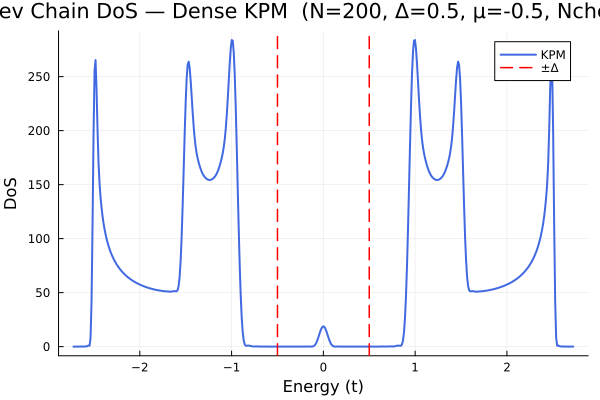

In [27]:
p_dos = plot(ω_dos, dos;
     xlabel="Energy (t)", ylabel="DoS",
     title="Kitaev Chain DoS — Dense KPM  (N=$(N), Δ=$(Δ), μ=$(μ), Ncheb=$(Ncheb))",
     legend=:topright, lw=2, color=:royalblue, label="KPM")
vline!(p_dos, [-Δ, Δ]; ls=:dash, color=:red, lw=1.5, label="±Δ")

In [ ]:
η = 0.05   # Lorentzian broadening width

evals_exact = real.(eigvals(Hermitian(H_BdG)))

dos_exact = map(ω_dos) do ω
    sum(η / (π * ((ω - ε)^2 + η^2)) for ε in evals_exact)
end



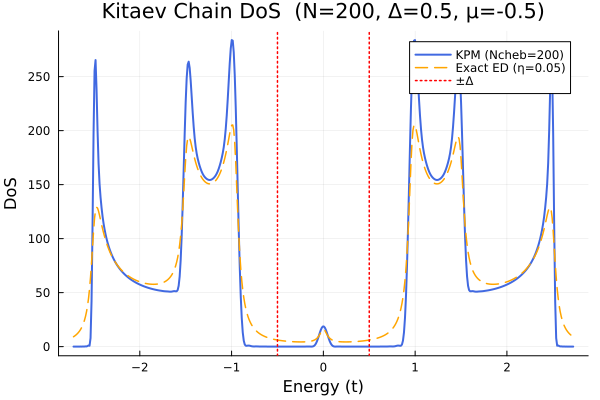

In [28]:
p_comparison = plot(ω_dos, dos;
     xlabel="Energy (t)", ylabel="DoS",
     title="Kitaev Chain DoS  (N=$(N), Δ=$(Δ), μ=$(μ))",
     lw=2, color=:royalblue, label="KPM (Ncheb=$(Ncheb))")
plot!(p_comparison, ω_dos, dos_exact;
      lw=1.5, color=:orange, ls=:dash, label="Exact ED (η=$(η))")
vline!(p_comparison, [-Δ, Δ]; ls=:dot, color=:red, lw=1.5, label="±Δ")

In [30]:
mkpath("figs")
savefig(p_heatmap,    "figs/bdg_heatmap.png")
savefig(p_dos,        "figs/dos_kpm.png")
savefig(p_comparison, "figs/dos_comparison.png")
println("Saved 3 figures to examples/figs/")

Saved 3 figures to examples/figs/
